In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, t
import itertools as it
from matplotlib import rcParams
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from utils.constants import chambers_ordered
from string import ascii_lowercase
from utils.paths import path_out 

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract')

clist = ['#05dbfc', "#3730ff", '#ffa500', '#ff0000']

name_list = ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$']

In [2]:
def plot_regression(ax, x, y, color, ls, lw=3, add_ci=False):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    res = linregress(x, y)
    slope = res.slope
    intercept = res.intercept
    se_slope = res.stderr
    se_intercept = res.intercept_stderr  # linregress provides this directly

    # residual standard error for confidence band
    y_pred = slope * x + intercept
    residuals = y - y_pred
    n = len(x)
    s_res = np.sqrt(np.sum(residuals**2) / (n - 2))  # residual std error

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = slope * x_fit + intercept
    t_val = t.ppf(0.975, df=n-2)
    x_mean = x.mean()
    se_fit = s_res * np.sqrt(1/n + (x_fit - x_mean)**2 / ((x - x_mean)**2).sum())

    ax.plot(x_fit, y_fit, color=color, linewidth=lw, linestyle=ls, zorder=3)
    if add_ci:
        ax.fill_between(x_fit, y_fit - t_val*se_fit, y_fit + t_val*se_fit, color=color, alpha=0.1, zorder=2)

    return np.mean(y), slope, se_slope, intercept, se_intercept # mean, slope, slope's stderr, intercept, intercept's stderr

In [3]:
def get_pre2021_obs():
    VAR_LIST = ['AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
                'BGNPP_TreeShrub', 'NPP', 'HR']
    VAR_STD = [53.5/90.5, 32/73, 35/92.1, 67/208, 4.8/3.4, (129.419256 + 134.94) / (391.26 + 384.87), 53/283]

    obs_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                    'extract_obs_productivity.csv'), index_col = [0, 1])
    # restrict to pre-2021
    obs_data = obs_data.loc[obs_data.index.get_level_values('Year') <= 2021, :]

    obs_data.index.names = ['plot','year']

    return obs_data, VAR_LIST, VAR_STD


def get_pre2021_sim(prefix, VAR_LIST):
    sim_temp = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                        prefix, 'extract_ts_productivity.csv'), index_col = [0, 1, 2]).loc['average', :]
    # restrict to pre-2021
    sim_temp = sim_temp.loc[sim_temp.index.get_level_values('year') <= 2022, :]

    # restrict to variables
    sim_temp = sim_temp.loc[:, ['Tair'] + VAR_LIST]

    return sim_temp

In [4]:
def get_post2021_obs():
    """ Collect 2022-2023 data """
    VAR_LIST_2023 = ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub'] # [v for v in VAR_LIST if not v == 'NPP_moss' and not v == 'NPP']
    VAR_STD_2023 = [53.5/90.5, 32/73, 35/92.1, 53/283] # 4.8/3.4, 

    # Tree AGNPP are only observed in 2022
    # Shrub AGNPP only observed in 2023
    obs_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                        'extract_obs_productivity.csv'), index_col = [0, 1])
    # restrict to post-2021
    obs_data = obs_data.loc[obs_data.index.get_level_values('Year') >= 2022, ['Tair'] + VAR_LIST_2023]
    # rename Index names to be compatible with sims
    obs_data.index.names = ['plot','year']

    ############################################################################
    # For the small collar comparison, the GPP and autotrophic respiration of 
    # modeled values should be scaled down to conform to the small collar biomass
    ############################################################################
    # unit: g dry weight
    # collar size: 0.5 m diameter => 0.1963 m2
    collar_biomass = pd.read_excel(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'input',
                                                'Chamber Biomass_edits_JMB.xlsx'))
    # vaan: Vaccinium angustifolium
    # kapo: Kalmia polifolia
    # vaox: Vaccinium oxycoccos
    # ersp: Eriophorum spp.
    # mitr: probably an herb
    # mush: mushroom?
    # dead: dead stuff that was clipped in each chamber, collected in separate bags
    # bstem: stem below the top of sphagnum -  collected in separate bags
    # nsm: non-sphagnum moss
    collar_biomass = collar_biomass.drop(['age','part','dead'], axis = 1).groupby(['ChamberNumber','plot']).sum().groupby('plot').mean()
    collar_biomass['Shrub'] = collar_biomass[['rhgr','chca','vaan','kapo','vaox','ersp','bstem','betula']].sum(axis = 1)
    collar_biomass['Sphagnum'] = collar_biomass[['sphag','nsm']].sum(axis = 1)
    collar_biomass = collar_biomass[['Shrub','Sphagnum']]
    collar_biomass.index.name = 'Plot'

    plot_biomass = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'input', 'SPRUCE_AGB&ANPP_CNP_PerTissue_20260123.csv'))
    plot_biomass['Plot'] = [f'P{p:02g}' for p in plot_biomass['Plot']]
    plot_biomass = plot_biomass.groupby(['Year','Plot','PFT']).sum()['SumAGB_gDMperm2'].unstack().loc[2023, ['Shrub','Sphagnum']].dropna(how='any', axis = 0)

    collar_ratio = (collar_biomass / 0.1963) / plot_biomass

    obs_data = obs_data.rename({'HR':'NEE_ShrubMoss'})
    nee = nee = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                'extract_obs_small_collar', 'nee_pred.csv'))
    nee = nee[['Plot','Reco_pred Q10+Wh','GPP_pred PAR+Wh+Tair']].groupby('Plot').mean()
    # unit conversion: umol m-2 s-1 => gC m-2 year-1
    nee = nee * 1e-6 * 12 * 86400 * 365
    nee = nee['Reco_pred Q10+Wh'] - nee['GPP_pred PAR+Wh+Tair']
    for plot in nee.index:
        # convert unit from day-1 to yr-1
        obs_data.loc[(plot,2023), 'NEE_ShrubMoss'] = nee.loc[plot]
    VAR_LIST_2023.append('NEE_ShrubMoss')

    reco_std = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                'extract_obs_small_collar', 'nighttime_params_Q10+Wh.csv'),index_col=0)
    gpp_std = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                'extract_obs_small_collar', 'daytime_params_PAR+Wh+Tair.csv'),index_col=0)
    # uncertainty of mean values decreases with sqrt(N)
    nee_std = (reco_std['RMSE']**2 + gpp_std['RMSE']**2).mean() / np.sqrt(365*48)
    # unit conversion
    nee_std = nee_std * 1e-6 * 12 * 86400 * 365
    VAR_STD_2023.append(nee_std)

    return obs_data, collar_ratio, VAR_LIST_2023, VAR_STD_2023


def get_post2021_sim(prefix, collar_ratio, VAR_LIST_2023):
    sim_temp = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                        prefix, 'extract_ts_productivity.csv'), index_col = [0, 1, 2]).loc['average', :]
    # restrict to post-2021
    sim_temp = sim_temp.loc[sim_temp.index.get_level_values('year') >= 2022, :]

    # Calculate the RECO for shrub-moss community
    sim_temp2 = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                         prefix, 'extract_ts_productivity.csv'), index_col = [0, 1, 2]).loc['average', :]
    sim_temp2 = sim_temp2.loc[sim_temp2.index.get_level_values('year') == 2023, :]
    temp = sim_temp2['HR'] + sim_temp2['MR_Spruce']*(1-sim_temp2['AGBiomass_Spruce']/sim_temp2['TOTVEGC_Spruce']) \
         + sim_temp2['MR_Tamarack']*(1-sim_temp2['AGBiomass_Tamarack']/sim_temp2['TOTVEGC_Tamarack'])
    for plot in sim_temp2.index.levels[0]:
        if plot == 'P07':
            sim_temp2.loc[(plot, 2023), 'NPP_moss'] = np.nan
            sim_temp2.loc[(plot, 2023), 'NPP_Shrub'] = np.nan
        else:
            sim_temp2.loc[(plot, 2023), 'NPP_moss'] *= collar_ratio.loc[plot,'Sphagnum']
            sim_temp2.loc[(plot, 2023), 'NPP_Shrub'] *= collar_ratio.loc[plot,'Shrub']
    sim_temp['NEE_ShrubMoss'] = temp - sim_temp2['NPP_moss'] - sim_temp2['NPP_Shrub']

    # restrict to variables
    sim_temp = sim_temp.loc[:, ['Tair'] + VAR_LIST_2023]

    return sim_temp

In [5]:
def plot_general(var_list, var_list_names, var_uncertainty, all_data):
    prefix_list = list(all_data.keys())
    prefix_list.remove('Obs')

    all_data = pd.concat(all_data, axis=1).swaplevel(0, 1, axis = 1).sort_index(axis = 1)

    rmse = {}
    rae_mean = {}
    rae_slope = {}
    for prefix, var in it.product(prefix_list, var_list):
        rmse[(prefix,var)] = []
        rae_mean[(prefix,var)] = []
        rae_slope[(prefix,var)] = []

    ncols = int(np.ceil(np.sqrt(len(var_list))))
    nrows = int(np.ceil(len(var_list)/ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4*nrows), sharex=True, sharey=False)

    # --- accumulate regression stats ---
    records = []

    for i, (var,var_label) in enumerate(zip(var_list, var_list_names)):
        ax = axes.flat[i]

        for j, (co2, ls) in enumerate(zip(['amb', 'elev'], ['-',':'])):
            idx = chambers_ordered[co2]

            tair_obs = all_data.loc[idx, ('Tair', 'Obs')].values
            obs_temp = all_data.loc[idx, (var, 'Obs')].values

            # Obs vs Tair
            if co2 == 'amb':
                ax.scatter(tair_obs, obs_temp, edgecolors='k', s=10, facecolors='k', zorder=1, alpha=0.25)
            else:
                ax.scatter(tair_obs, obs_temp, edgecolors='k', s=10, facecolors='none', zorder=1, alpha=0.25)
            mean_obs, slope_obs, slope_std_obs, intercept_obs, intercept_std_obs = plot_regression(ax, tair_obs, obs_temp, color='k', ls=ls, add_ci=True)

            records.append({
                'var': var, 'prefix': 'Obs', 'co2': co2,
                'intercept': intercept_obs, 'intercept_std': intercept_std_obs,
                'slope': slope_obs, 'slope_std': slope_std_obs,
            })

            for p, prefix in enumerate(prefix_list):

                tair_sim = all_data.loc[idx, ('Tair', prefix)].values
                sim_temp = all_data.loc[idx, (var, prefix)].values

                #if co2 == 'amb':
                #    ax.scatter(tair_sim, sim_temp, edgecolors=clist[p], s=10, facecolors=clist[p], zorder=1, alpha=0.5)
                #else:
                #    ax.scatter(tair_sim, sim_temp, edgecolors=clist[p], s=10, facecolors='none', zorder=1, alpha=0.5)
                mean, slope, slope_std, intercept, intercept_std = plot_regression(ax, tair_sim, sim_temp, color=clist[p], ls=ls, add_ci=True)

                records.append({
                    'var': var, 'prefix': prefix, 'co2': co2,
                    'intercept': intercept, 'intercept_std': intercept_std,
                    'slope': slope, 'slope_std': slope_std,
                })

                # record the performance
                rmse[(prefix,var)].append( np.sqrt(np.nanmean(np.power(sim_temp - obs_temp,2))) )
                rae_mean[(prefix,var)].append( (mean - mean_obs)/(mean_obs*var_uncertainty[i]) )
                rae_slope[(prefix,var)].append( (slope - slope_obs)/slope_std_obs )

        panel_below = i + ncols
        is_bottom_exposed = (panel_below >= len(var_list))

        if is_bottom_exposed:
            ax.set_xlabel('Air temperature ($^o$C)')

        if var == 'NEE_ShrubMoss':
            ax.set_ylabel(var_label + ' (gC m$^{-2}$ yr$^{-1}$)')
        else:
            ax.set_ylabel(var_label + ' (gC m$^{-2}$ yr$^{-1}$)')

        legend_handles = [
            mlines.Line2D([], [], color='k',  linewidth=2, linestyle='-', label='Ambient CO$_2$'),
            mlines.Line2D([], [], color='k',  linewidth=2, linestyle=':', label='Elevated CO$_2$'),
            mlines.Line2D([], [], color='k',  linewidth=2, marker='o', markersize=5, label='Observed'),
            *[mlines.Line2D([], [], color=clist[p], linewidth=2, marker='o', markersize=5, label=name_list[p]) for p in range(len(prefix_list))]
        ]
        ax.text(0.05, 0.95, ascii_lowercase[i], fontweight='bold', transform=ax.transAxes)

    for i, var in enumerate(var_list):
        ax = axes.flat[i]
        ax.text(0.,1.05,'RMSE=',transform=ax.transAxes,color='k',va='center',fontsize=12)
        for p, prefix in enumerate(prefix_list):
            rmse_temp = np.sqrt(np.nanmean(np.power(rmse[(prefix,var)],2)))
            ax.text(0.21+p*0.2, 1.05, f'{rmse_temp:.2f}', transform=ax.transAxes,
                    va='center', color=clist[p],fontsize=12)

    if len(var_list) < len(axes.flat):
        for i in range(len(var_list), len(axes.flat)):
            axes.flat[i].axis('off')
        
        # end of plotting area
        xend = 1 - (len(axes.flat)-len(var_list))/ncols
        yend = 1/nrows

        fig.legend(handles=legend_handles, ncols = 2, loc='upper left', bbox_to_anchor = (xend, yend))

        for p, prefix in enumerate(prefix_list):
            rae = 0
            for i, var in enumerate(var_list):
                if var != 'NPP':
                    rae += np.mean(np.abs(rae_mean[(prefix,var)])) + np.mean(np.abs(rae_slope[(prefix,var)]))
            rae /= (i+1)
            fig.text(xend + (1-xend)/len(prefix_list)*p, 0.2, f'RAE={rae:.2f}', va='top', color=clist[p])

    else:

        fig.legend(handles=legend_handles, ncols = 4, loc='upper left', bbox_to_anchor = (0, -0.007))

        for p, prefix in enumerate(prefix_list):
            rae = 0
            for i, var in enumerate(var_list):
                if var != 'NPP':
                    rae += np.mean(np.abs(rae_mean[(prefix,var)])) + np.mean(np.abs(rae_slope[(prefix,var)]))
            rae /= (i+1)
            fig.text(0.05 + p*0.20, 0.01, f'RAE={rae:.2f}', va='top', color=clist[p])

    plt.tight_layout()

    # return fig, axes

    # --- build and return DataFrame, avoid sorting the frames ---
    desired_order = [(vv,pp,cc) for vv in var_list for pp in ['Obs']+prefix_list for cc in ['amb','elev']]
    df_stats = pd.DataFrame(records).set_index(['var','prefix','co2'])
    df_stats = df_stats.loc[desired_order, :]

    return df_stats

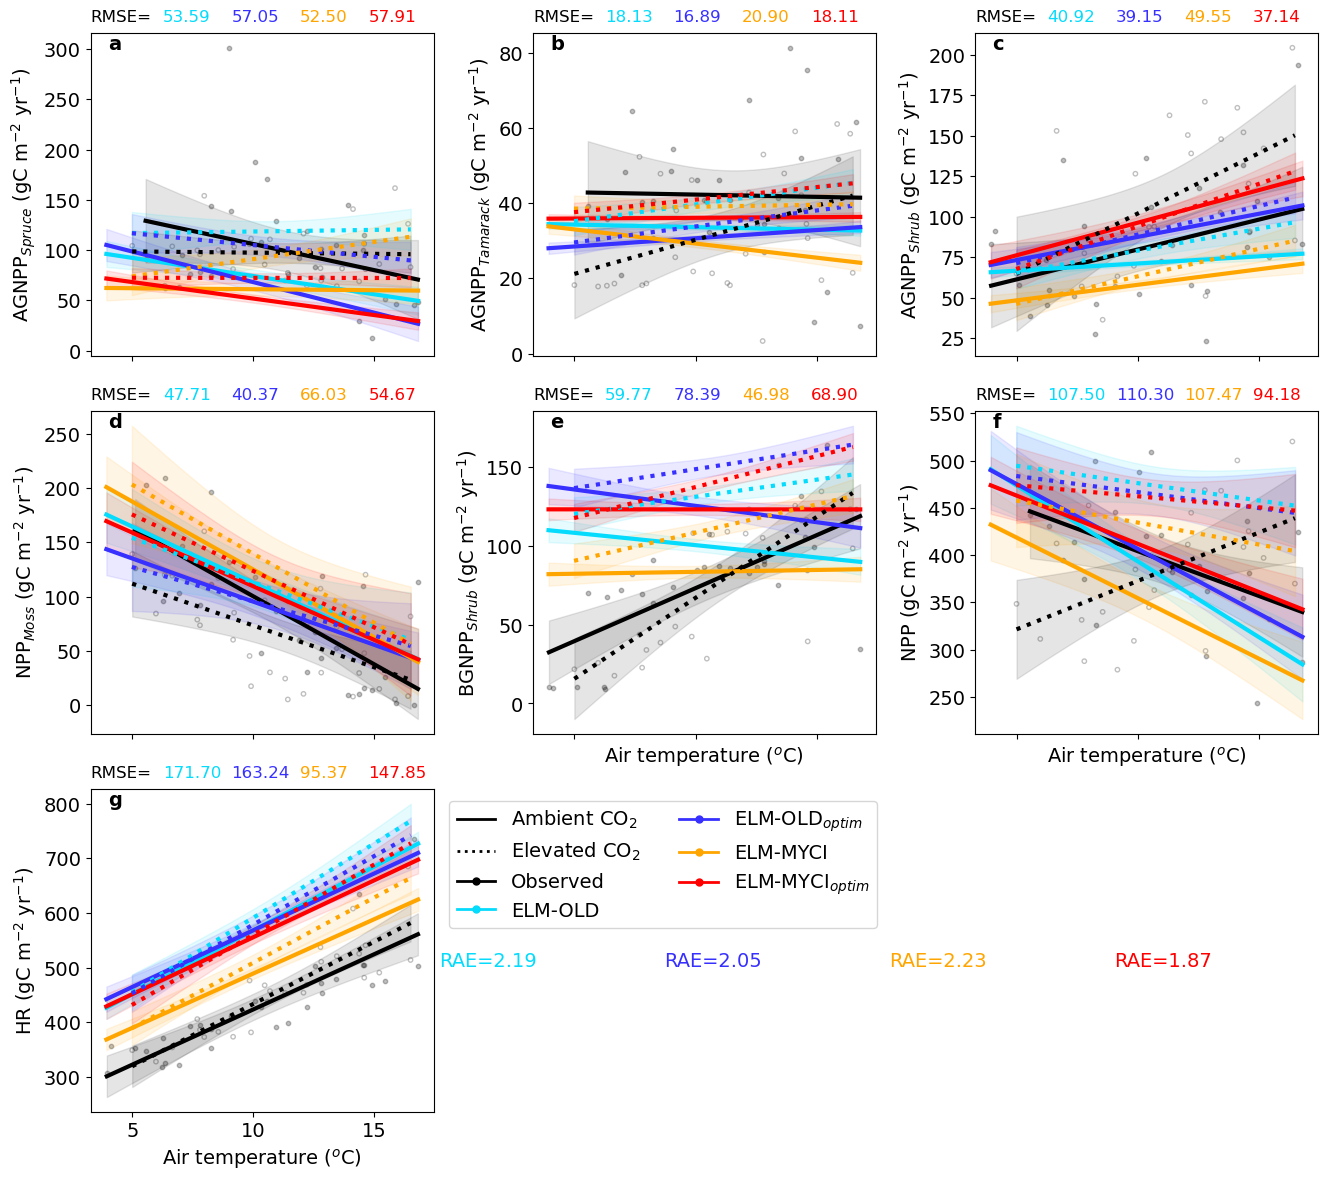

In [6]:
all_data_pre2021 = {}

# Add the small collar measured NEE and uncertainty for the shrub-moss community
obs_data, VAR_LIST, VAR_STD = get_pre2021_obs()

all_data_pre2021['Obs'] = obs_data
for p, prefix in enumerate(['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']):
    sim_temp = get_pre2021_sim(prefix, VAR_LIST)
    all_data_pre2021[prefix] = sim_temp

df_stats = plot_general(VAR_LIST, [r'AGNPP$_{Spruce}$', r'AGNPP$_{Tamarack}$', r'AGNPP$_{Shrub}$', r'NPP$_{Moss}$',
                                   r'BGNPP$_{Shrub}$', 'NPP', 'HR'], VAR_STD, all_data_pre2021)
df_stats.to_csv(os.path.join(path_out, 'plot_carbonfluxes_regression_results_pre2021.csv'))

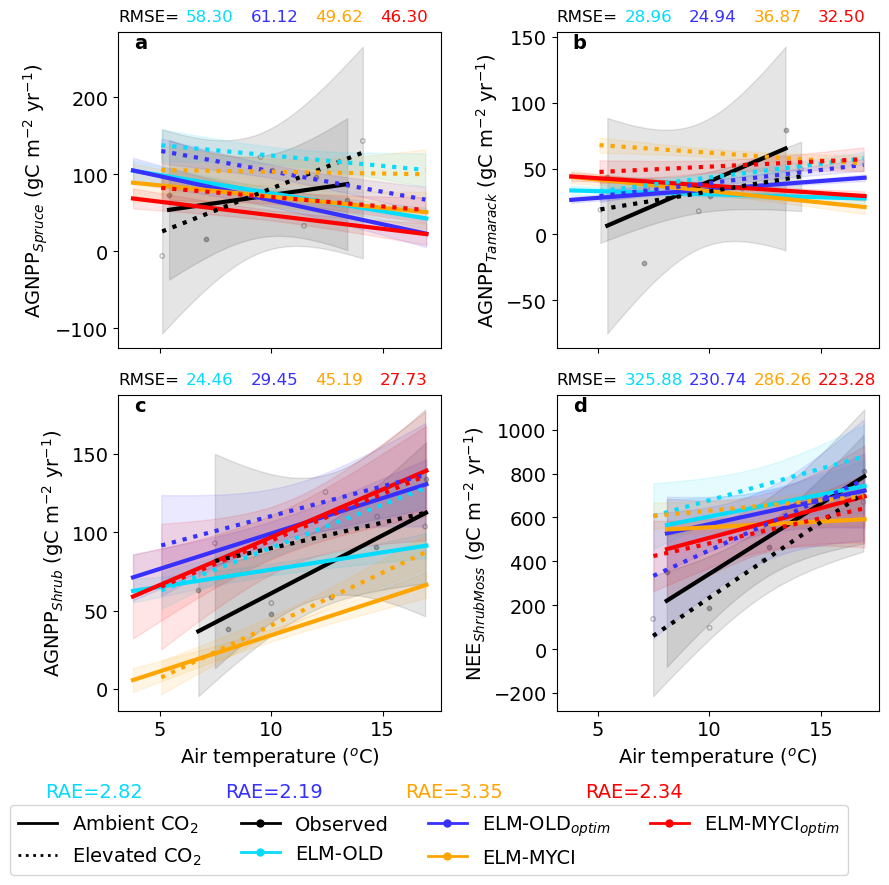

In [7]:
all_data_post2021 = {}

# Add the small collar measured NEE and uncertainty for the shrub-moss community
obs_data, collar_ratio, VAR_LIST_2023, VAR_STD_2023 = get_post2021_obs()

all_data_post2021['Obs'] = obs_data
for p, prefix in enumerate(['20260226_default_default','20260226_default_optim','20260226_MYCI_default','20260226_MYCI_optim']):
    sim_temp = get_post2021_sim(prefix, collar_ratio, VAR_LIST_2023)
    all_data_post2021[prefix] = sim_temp

df_stats = plot_general(VAR_LIST_2023, [r'AGNPP$_{Spruce}$', r'AGNPP$_{Tamarack}$', r'AGNPP$_{Shrub}$', r'NEE$_{ShrubMoss}$'], 
                        VAR_STD_2023, all_data_post2021)
df_stats.to_csv(os.path.join(path_out, 'plot_carbonfluxes_regression_results_post2021.csv'))

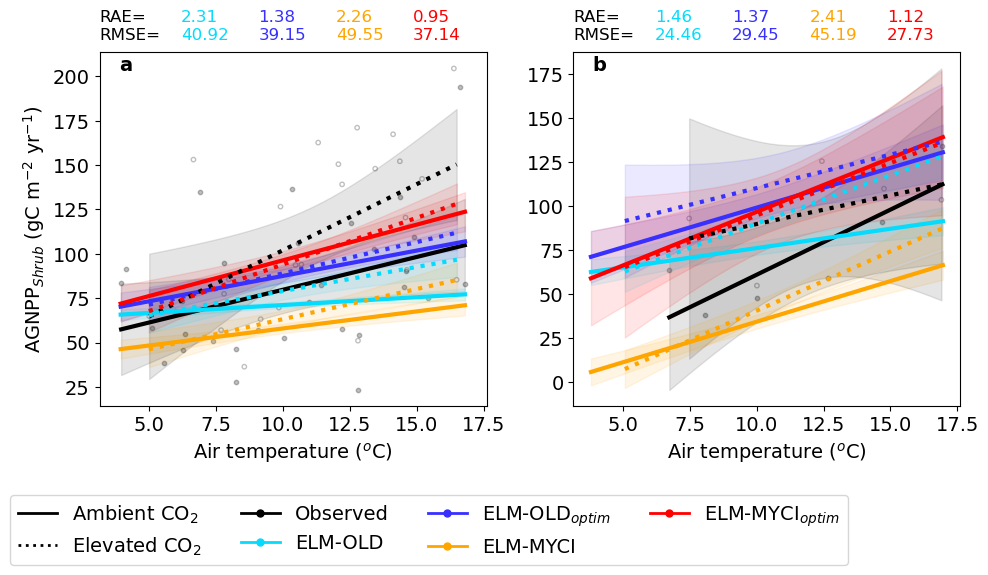

In [8]:
################################################
# Compile shrub results into a single graph
################################################
def plot_shrub(all_data1, all_data2):

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=False)

    for i, all_data in enumerate([all_data1, all_data2]):
        
        prefix_list = list(all_data.keys())
        prefix_list.remove('Obs')
        all_data = pd.concat(all_data, axis=1).swaplevel(0, 1, axis = 1).sort_index(axis = 1)

        rmse = {}
        rae_mean = {}
        rae_slope = {}
        for prefix in prefix_list:
            rmse[prefix] = []
            rae_mean[prefix] = []
            rae_slope[prefix] = []

        ax = axes.flat[i]

        for j, (co2, ls) in enumerate(zip(['amb', 'elev'], ['-',':'])):
            idx = chambers_ordered[co2]

            tair_obs = all_data.loc[idx, ('Tair', 'Obs')].values
            obs_temp = all_data.loc[idx, ('AGNPP_Shrub', 'Obs')].values

            # Obs vs Tair
            if co2 == 'amb':
                ax.scatter(tair_obs, obs_temp, edgecolors='k', s=10, facecolors='k', zorder=1, alpha=0.25)
            else:
                ax.scatter(tair_obs, obs_temp, edgecolors='k', s=10, facecolors='none', zorder=1, alpha=0.25)
            mean_obs, slope_obs, slope_std_obs, intercept_obs, intercept_std_obs = plot_regression(ax, tair_obs, obs_temp, color='k', ls=ls, add_ci=True)

            for p, prefix in enumerate(prefix_list):

                tair_sim = all_data.loc[idx, ('Tair', prefix)].values
                sim_temp = all_data.loc[idx, ('AGNPP_Shrub', prefix)].values

                #if co2 == 'amb':
                #    ax.scatter(tair_sim, sim_temp, edgecolors=clist[p], s=10, facecolors=clist[p], zorder=1, alpha=0.5)
                #else:
                #    ax.scatter(tair_sim, sim_temp, edgecolors=clist[p], s=10, facecolors='none', zorder=1, alpha=0.5)
                mean, slope, slope_std, intercept, intercept_std = plot_regression(ax, tair_sim, sim_temp, color=clist[p], ls=ls, add_ci=True)

                rmse[prefix].append( np.sqrt(np.nanmean(np.power(sim_temp - obs_temp,2))) )
                rae_mean[prefix].append( (mean - mean_obs)/(mean_obs*35/92.1) )
                rae_slope[prefix].append( (slope - slope_obs)/slope_std_obs )

        ax.set_xlabel('Air temperature ($^o$C)')

        if i == 0:
            ax.set_ylabel('AGNPP$_{Shrub}$ (gC m$^{-2}$ yr$^{-1}$)')

        legend_handles = [
            mlines.Line2D([], [], color='k',  linewidth=2, linestyle='-', label='Ambient CO$_2$'),
            mlines.Line2D([], [], color='k',  linewidth=2, linestyle=':', label='Elevated CO$_2$'),
            mlines.Line2D([], [], color='k',  linewidth=2, marker='o', markersize=5, label='Observed'),
            *[mlines.Line2D([], [], color=clist[p], linewidth=2, marker='o', markersize=5, label=name_list[p]) for p in range(len(prefix_list))]
        ]
        ax.text(0.05, 0.95, ascii_lowercase[i], fontweight='bold', transform=ax.transAxes)

        ax.text(0.,1.05,'RMSE=',transform=ax.transAxes,color='k',va='center',fontsize=12)
        ax.text(0.,1.1,'RAE=',transform=ax.transAxes,color='k',va='center',fontsize=12)
        for p, prefix in enumerate(prefix_list):
            rmse_temp = np.sqrt(np.nanmean(np.power(rmse[prefix],2)))
            ax.text(0.21+p*0.2, 1.05, f'{rmse_temp:.2f}', transform=ax.transAxes,
                    va='center', color=clist[p],fontsize=12)

            rae = np.mean(np.abs(rae_mean[prefix])) + np.mean(np.abs(rae_slope[prefix]))
            ax.text(0.21+p*0.2, 1.1, f'{rae:.2f}', transform=ax.transAxes,
                    va='center', color=clist[p],fontsize=12)


    fig.legend(handles=legend_handles, ncols = 4, loc='upper left', bbox_to_anchor = (0, 0))

    plt.tight_layout()

plot_shrub(all_data_pre2021, all_data_post2021)

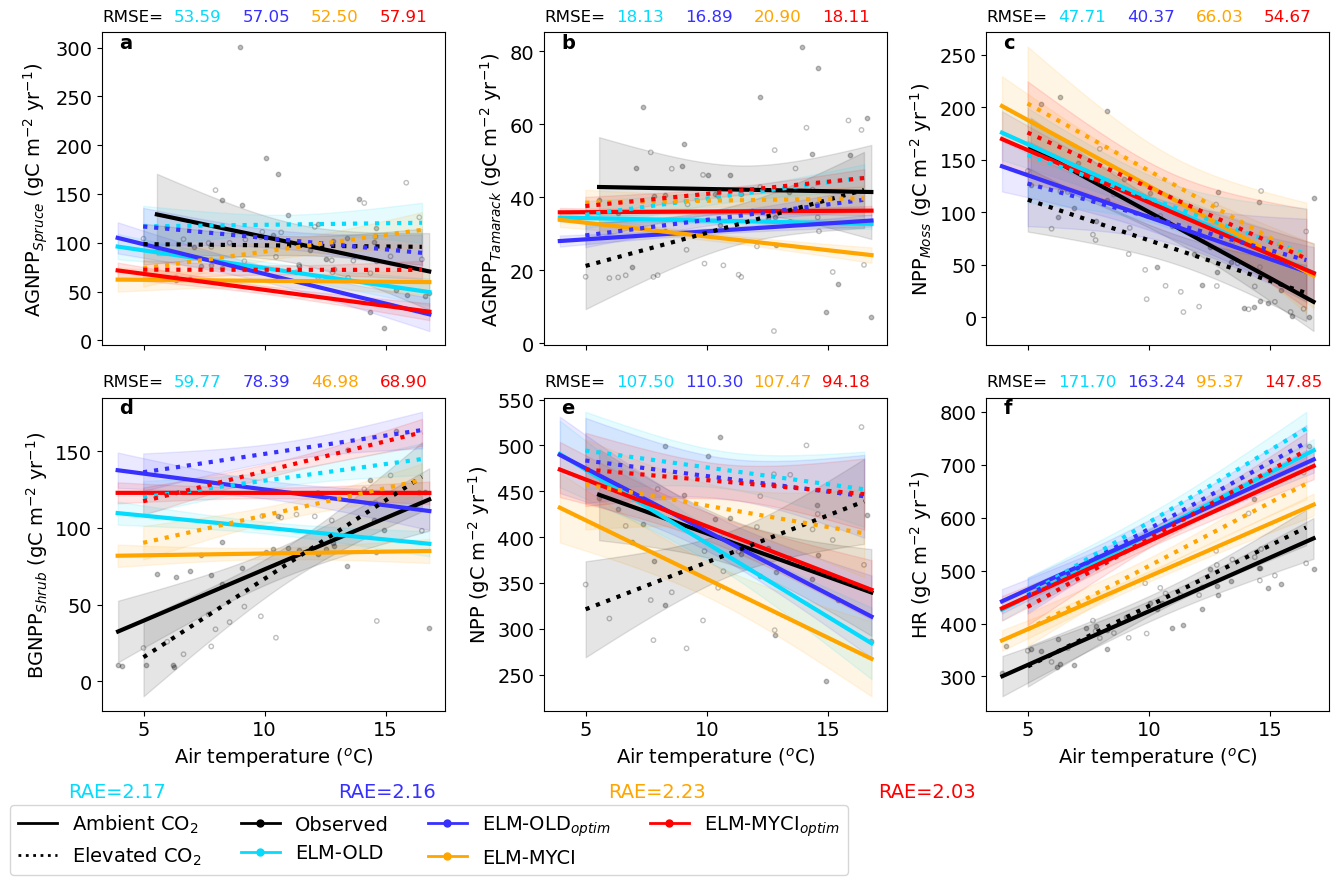

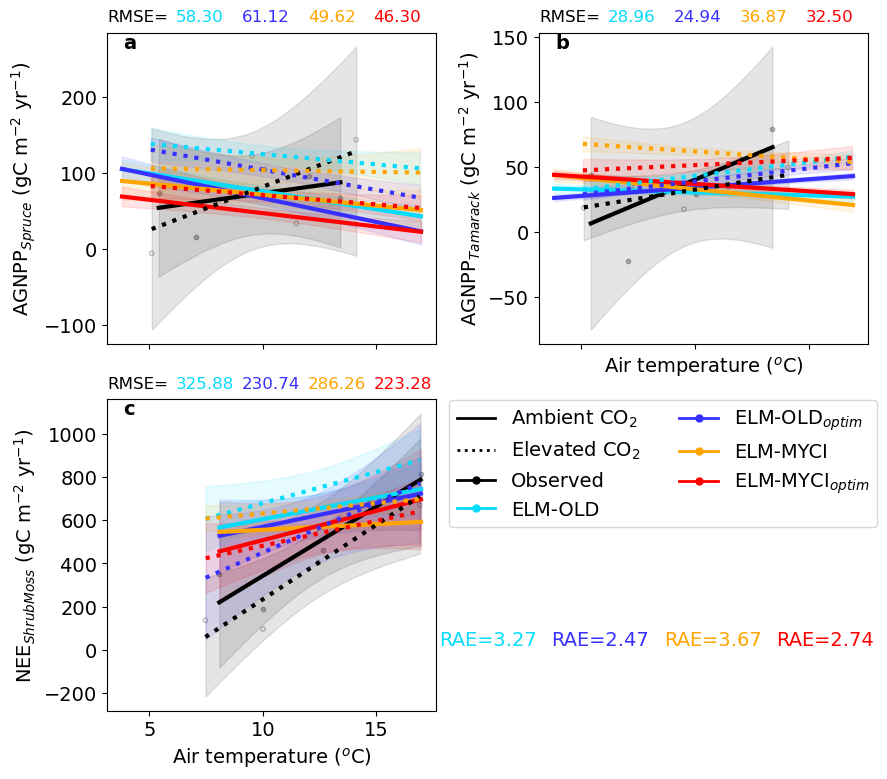

In [9]:
################################################################################
# Manually edit these figures in power point to merge into a single SI figure
# Skip the display of RAE values because 
################################################################################
_ = plot_general(VAR_LIST[:2]+VAR_LIST[3:], [r'AGNPP$_{Spruce}$', r'AGNPP$_{Tamarack}$', r'NPP$_{Moss}$',
                                             r'BGNPP$_{Shrub}$', 'NPP', 'HR'], VAR_STD[:2]+VAR_STD[3:], all_data_pre2021)
_ = plot_general(VAR_LIST_2023[:2]+VAR_LIST_2023[3:], [r'AGNPP$_{Spruce}$', r'AGNPP$_{Tamarack}$', r'NEE$_{ShrubMoss}$'], 
                 VAR_STD_2023[:2]+VAR_STD_2023[3:], all_data_post2021)